In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

Напишите такую функцию визуализации plot_mask_over_image(), которая бы накладывала полупрозрачную маску на исходное изображение airplane_image.jpg. Вот так может выглядеть конечный результат:

In [ ]:
image_png = 'image.png'

TypeError: Image data of dtype <U9 cannot be converted to float

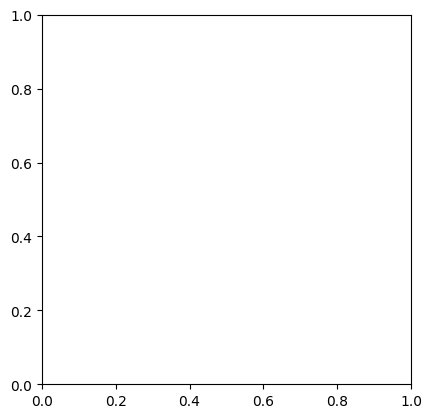

In [ ]:
plt.imshow(image_png)

In [ ]:
orig_img: np.ndarray = None
class_mask: np.ndarray = None 
colormap: np.ndarray = None

In [ ]:
def plot_mask_over_image(orig_img: np.ndarray, class_mask: np.ndarray, colormap: np.ndarray) -> np.ndarray:
    # напишите реализацию функции
    ...




In [ ]:
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# Для примера задаём пустую маску, при встраивании в конечное решение будет использоваться результат инференса
h, w = img.shape[:2]
masked_image = np.zeros((h, w), dtype=np.uint8)
viz = plot_mask_over_image(np.array(img), masked_image)
plt.imshow(viz)
plt.show()

In [6]:
COLORMAP = np.array(
    [
        [0, 0, 0],  # background (black)
        [128, 0, 0],  # aeroplane (dark red)
        [0, 128, 0],  # bicycle (green)
        [128, 128, 0],  # bird (yellow-green)
        [0, 0, 128],  # boat (blue)
        [128, 0, 128],  # bottle (purple)
        [0, 128, 128],  # bus (teal)
        [128, 128, 128],  # car (gray)
        [64, 0, 0],  # cat (brown)
        [192, 0, 0],  # chair (red)
        [64, 128, 0],  # cow (olive)
        [192, 128, 0],  # diningtable (orange)
        [64, 0, 128],  # dog (indigo)
        [192, 0, 128],  # horse (pink)
        [64, 128, 128],  # motorbike (cyan)
        [192, 128, 128],  # person (light pink)
        [0, 64, 0],  # pottedplant (dark green)
        [128, 64, 0],  # sheep (mustard)
        [0, 192, 0],  # sofa (bright green)
        [128, 192, 0],  # train (lime)
        [0, 64, 128],  # tvmonitor (navy)
    ],
    dtype=np.uint8,
)

CLASSES = [
    "background",
    "aeroplane",
    "bicycle",
    "bird",
    "boat",
    "bottle",
    "bus",
    "car",
    "cat",
    "chair",
    "cow",
    "diningtable",
    "dog",
    "horse",
    "motorbike",
    "person",
    "pottedplant",
    "sheep",
    "sofa",
    "train",
    "tvmonitor",
]

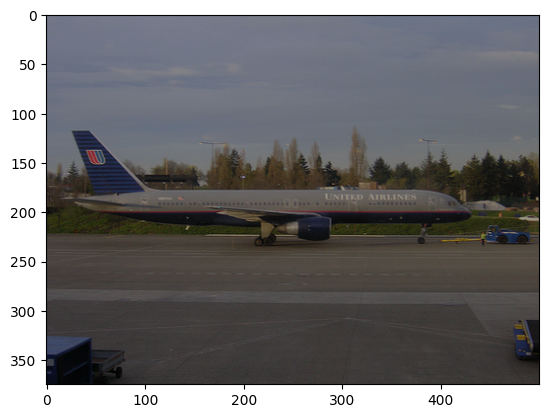

In [7]:
import numpy as np
import cv2
import matplotlib.pyplot as plt


def plot_mask_over_image(orig_img: np.ndarray, class_mask: np.ndarray, colormap: np.ndarray) -> np.ndarray:
    alpha = 0.6

    colored_mask = colormap[class_mask]
    viz = orig_img.copy()
    h, w = viz.shape[:2]
    colored_mask = cv2.resize(colored_mask, (w, h))
    mask_over_image_viz = cv2.addWeighted(
        viz,
        alpha,
        colored_mask,
        1 - alpha,
        0,
    )
    return mask_over_image_viz

img_path = 'image.png'
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# Для примера задаём пустую маску, при встраивании в конечное решение будет использоваться результат инференса
h, w = img.shape[:2]
masked_image = np.zeros((h, w), dtype=np.uint8)
viz = plot_mask_over_image(np.array(img), masked_image, COLORMAP)
plt.imshow(viz)
plt.show()

In [ ]:
import torch
import cv2
import torchvision.transforms as T
from torchvision.models.segmentation import fcn_resnet50
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from typing import Dict, List, Tuple
from torchvision.transforms.functional import InterpolationMode
from torchvision.models.segmentation import FCN



def load_model_for_inference() -> FCN:
    """Напишите код загрузки модели, готовой для инференса"""


def model_input_pipeline(image_path: str) -> torch.Tensor:
    """Напишите пайплайн препроцессинга"""


def raw_tensor_to_class_mask(raw_CHW_logits: torch.Tensor) -> np.ndarray:
    """Напишите код, который парсит маску классов из логитов"""


def make_segmentation_results_plot(
    orig_image: np.ndarray,
    classes_mask: np.ndarray,
    colormap: np.ndarray,
    classes_names: List[str],
) -> None:
    """Код Визуализации"""


def inference_pipeline(img_path: str) -> None:
    model = load_model_for_inference()
    input_image = model_input_pipeline(img_path)
    output_mask = None  # Напишите код инференса и извлечения маски классов
    orig_img = Image.open(img_path)
    make_segmentation_results_plot(orig_img, output_mask, COLORMAP, CLASSES)


inference_pipeline("sparrow.jpg")